# Laboratorio Semana 2: CNN Completa con Forward y Backward Pass

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible

---

## Contexto

En la clase de la Semana 1 usted implemento backpropagation sobre una regresion logistica. Esta semana va a implementar el pipeline completo de una red neuronal convolucional: forward pass y backward pass sobre una imagen real del dataset de digitos de scikit-learn.

La arquitectura es la siguiente:

```
Imagen 8x8  ->  Conv(3x3) + bias  ->  ReLU  ->  MaxPool(2x2)  ->  Flatten  ->  Dense(9->1) + sigmoid  ->  Loss BCE
```

Usted implementara cada componente de esta cadena, tanto en la direccion hacia adelante como hacia atras.

## Reglas

- Utilice **unicamente NumPy**. No use PyTorch, TensorFlow, scipy ni ninguna funcion de convolucion o backpropagation de librerias externas.
- Las celdas que usted debe completar estan marcadas con `# SU CODIGO AQUI`.
- **No modifique las celdas de verificacion ni los pesos iniciales dados.**
- La celda final calcula su nota automatica sobre los 45 puntos de la seccion de codigo.

In [44]:
import numpy as np
import hashlib
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

def _hash_array(arr, decimals=5):
    """Huella criptografica reproducible de un arreglo NumPy."""
    return hashlib.sha256(np.round(arr, decimals).tobytes()).hexdigest()

_resultados = {}
print("Librerias cargadas.")

Librerias cargadas.


---
## Bloque 0: Datos y pesos iniciales (dado, no modificar)

Se utiliza el primer ejemplo del digito **0** del dataset `load_digits` de scikit-learn.  
La tarea es clasificacion binaria: predecir si la imagen corresponde al digito 0 (`y = 0`) o no.  
Los valores de pixel se normalizan al rango [0, 1] dividiendo entre 16.

Los pesos iniciales del kernel y la capa densa son fijos y estan definidos aqui.  
**No los cambie:** el autograder depende de estos valores exactos.

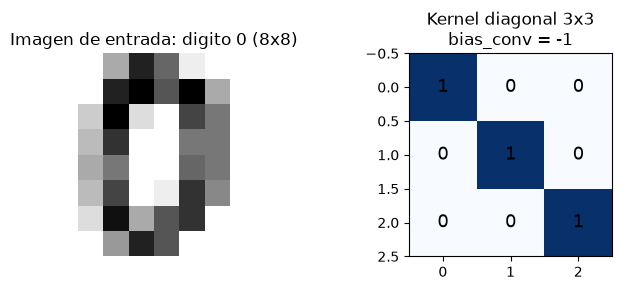

Imagen shape: (8, 8)
Label: 0
W_dense: [[ 0.17640523  0.04001572  0.0978738   0.22408932  0.1867558  -0.09772779
   0.09500884 -0.01513572 -0.01032189]]
b_dense: [0.]


In [45]:
# Datos
digits = load_digits()
idx_0  = np.where(digits.target == 0)[0][0]
imagen = digits.images[idx_0] / 16.0   # shape (8, 8)
label  = 0                              # binario: 0 = es un cero

# Pesos iniciales fijos
kernel    = np.array([[1,0,0],[0,1,0],[0,0,1]], dtype=float)  # 3x3 diagonal
bias_conv = -1.0

np.random.seed(0)
W_dense = np.random.randn(1, 9) * 0.1   # (1, 9)
b_dense = np.zeros(1)                    # (1,)

alpha = 0.01   # tasa de aprendizaje

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(imagen, cmap='gray_r')
axes[0].set_title('Imagen de entrada: digito 0 (8x8)')
axes[0].axis('off')
axes[1].imshow(kernel, cmap='Blues')
axes[1].set_title('Kernel diagonal 3x3\nbias_conv = -1')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, str(int(kernel[i,j])), ha='center', va='center', fontsize=13)
plt.tight_layout()
plt.savefig('b0_datos.png', dpi=110, bbox_inches='tight')
plt.show()
print("Imagen shape:", imagen.shape)
print("Label:", label)
print("W_dense:", W_dense)
print("b_dense:", b_dense)

---
## FORWARD PASS

---

## Bloque 1: Convolucion 2D

Implemente la convolucion 2D con stride = 1 y sin padding.  
Para cada posicion $(i,j)$ del feature map: extraiga la region, calcule el producto punto con el kernel, sume el bias.

La imagen es de 8x8 y el kernel de 3x3, por lo que el feature map de salida es de **6x6**.

**Importante:** guarde tambien la posicion del maximo en cada ventana de pooling durante el Bloque 3. Lo necesitara en el backward pass.

In [46]:
def convolucion_2d(img, kernel, bias):
    """
    Convolucion 2D, stride=1, sin padding.
    Retorna feature map de forma (n-f+1, n-f+1).
    """
    n = img.shape[0]
    f = kernel.shape[0]
    out_size = n - f + 1
    fm = np.zeros((out_size, out_size))

    for i in range(out_size):
        for j in range(out_size):

            # Regiones de dimenión fxf empezando en i, j.
            region = img[i : i + f, j : j + f]
            
            # Actualización de valor de feature map
            fm[i, j] = np.sum(region * kernel) + bias

    return fm


feature_map_pre = convolucion_2d(imagen, kernel, bias_conv)
print("Feature map pre-ReLU (6x6):")
print(np.round(feature_map_pre, 4))

Feature map pre-ReLU (6x6):
[[-0.0625 -0.0625  0.25    1.125   1.     -0.625 ]
 [-0.0625 -0.0625 -0.0625  0.4375  0.8125  0.4375]
 [-0.25   -0.0625 -0.0625 -0.3125  0.      0.1875]
 [ 0.     -0.25   -0.1875 -0.25    0.      0.    ]
 [ 0.125   0.3125  0.125  -0.1875 -0.25    0.    ]
 [-0.5     0.9375  0.625  -0.375  -0.1875 -0.25  ]]


In [47]:
# VERIFICACION BLOQUE 1
_H = 'bc77fd05203dc766f63f93ec008c3196517ae7185f3eabb946eb3757853a111e'
try:
    assert feature_map_pre is not None and hasattr(feature_map_pre, 'shape')
    assert feature_map_pre.shape == (6,6), f"Forma esperada (6,6), obtenida {feature_map_pre.shape}"
    assert _hash_array(feature_map_pre) == _H, "Valores incorrectos. Revise su implementacion."
    _resultados['b1'] = True; print("BLOQUE 1: CORRECTO")
except AssertionError as e:
    _resultados['b1'] = False; print(f"BLOQUE 1: INCORRECTO\n  {e}")

BLOQUE 1: CORRECTO


---
## Bloque 2: Activacion ReLU

Aplique ReLU elemento a elemento sobre `feature_map_pre`.  
No use `np.maximum` ni `np.clip`: implemente con una comparacion y una asignacion.

In [48]:
def relu(z):
    """
    ReLU elemento a elemento.
    No use np.maximum ni np.clip.
    """
    # Copia del array m x n de entrada
    arr = z.copy()
    
    # Obtener dimensiones del array
    m = arr.shape[0]
    n = arr.shape[1]

    # Iterar por todo el array
    for i in range(m):
        for j in range(n):
            # Cada valor en (i,j) = 0 si es negativo
            if arr[i, j] < 0:
                arr[i, j] = 0
    
    return arr

feature_map_relu = relu(feature_map_pre)
print("Feature map post-ReLU (6x6):")
print(np.round(feature_map_relu, 4))

Feature map post-ReLU (6x6):
[[0.     0.     0.25   1.125  1.     0.    ]
 [0.     0.     0.     0.4375 0.8125 0.4375]
 [0.     0.     0.     0.     0.     0.1875]
 [0.     0.     0.     0.     0.     0.    ]
 [0.125  0.3125 0.125  0.     0.     0.    ]
 [0.     0.9375 0.625  0.     0.     0.    ]]


In [49]:
# VERIFICACION BLOQUE 2
_H = 'abaaecd0d93c446237dba8f015f72396064c3dc810c55b74ca449cad636a139b'
try:
    assert feature_map_relu is not None and hasattr(feature_map_relu, 'shape')
    assert feature_map_relu.shape == (6,6), f"Forma esperada (6,6), obtenida {feature_map_relu.shape}"
    assert _hash_array(feature_map_relu) == _H, "Valores incorrectos. Revise su implementacion."
    _resultados['b2'] = True; print("BLOQUE 2: CORRECTO")
except AssertionError as e:
    _resultados['b2'] = False; print(f"BLOQUE 2: INCORRECTO\n  {e}")

BLOQUE 2: CORRECTO


---
## Bloque 3: Max Pooling 2x2 con stride 2

Aplique max pooling sobre `feature_map_relu` con ventana 2x2 y stride 2.  
El feature map de 6x6 produce un resultado de **3x3**.

**Ademas del resultado del pooling, guarde el indice (fila, columna) del maximo dentro de cada ventana** en el arreglo `pool_idx` de forma `(3, 3, 2)`.  
Estos indices son necesarios en el backward pass para saber a donde propagar el gradiente.

In [50]:
def max_pooling_2d(fm, pool_size=2, stride=2):
    """
    Max pooling 2D.
    Retorna:
      pooled   : np.ndarray de forma (out, out)
      pool_idx : np.ndarray de forma (out, out, 2) con indices (fila, col)
                 del maximo en la imagen original (no en la region local).
    """
    n = fm.shape[0]
    out_size = (n - pool_size) // stride + 1
    pooled   = np.zeros((out_size, out_size))
    pool_idx = np.zeros((out_size, out_size, 2), dtype=int)

    for i in range(out_size):
        for j in range(out_size):

            # Región de tamaño pool_size x pool_size en (i * stride, j * stride)
            region = fm[i * stride : i * stride + pool_size, j * stride : j * stride + pool_size]

            # Actualización de valor en pooled (i, j)
            pooled[i, j] = np.max(region)

            # Posición del máximo (n-esimo elemento)
            pos = np.argmax(region)

            # Coordenadas locales (region)
            r_local = pos // pool_size
            c_local = pos % pool_size

            # Coordenadas globales (fm)
            r_global = i * stride + r_local
            c_global = j * stride + c_local

            # Actualizar valor en pool_idx
            pool_idx[i, j] = [r_global, c_global]

    return pooled, pool_idx


pooled, pool_idx = max_pooling_2d(feature_map_relu, pool_size=2, stride=2)
print("Pooled (3x3):")
print(np.round(pooled, 4))
print("\nIndices del maximo (pool_idx shape):", pool_idx.shape)

Pooled (3x3):
[[0.     1.125  1.    ]
 [0.     0.     0.1875]
 [0.9375 0.625  0.    ]]

Indices del maximo (pool_idx shape): (3, 3, 2)


In [51]:
# VERIFICACION BLOQUE 3
_H = '2dc26d8a935302469c5393d2531fcbb460a1872fd41a87decf2203923e8a3510'
try:
    assert pooled is not None and hasattr(pooled, 'shape')
    assert pooled.shape == (3,3), f"Forma esperada (3,3), obtenida {pooled.shape}"
    assert pool_idx.shape == (3,3,2), f"pool_idx debe tener forma (3,3,2), obtenida {pool_idx.shape}"
    assert _hash_array(pooled) == _H, "Valores de pooled incorrectos. Revise su implementacion."
    _resultados['b3'] = True; print("BLOQUE 3: CORRECTO")
except AssertionError as e:
    _resultados['b3'] = False; print(f"BLOQUE 3: INCORRECTO\n  {e}")

BLOQUE 3: CORRECTO


---
## Bloque 4: Flatten, capa densa y sigmoid

Tres operaciones en secuencia:

1. **Flatten:** convierta `pooled` (3x3) en un vector de 9 elementos.
2. **Capa densa:** $z = W_{dense} \cdot flat + b_{dense}$, donde $W_{dense}$ es de forma (1,9) y $b_{dense}$ de forma (1,). El resultado $z$ es un escalar.
3. **Sigmoid:** $\hat{y} = \sigma(z) = \dfrac{1}{1+e^{-z}}$

Guarde los resultados en `flat`, `z_dense` y `y_hat` respectivamente.  
`y_hat` debe ser un escalar Python (tipo `float`), no un arreglo.

In [52]:
def sigmoid(z):
    """
    Funcion sigmoide.
    """
    return 1 / (1 + np.exp(-z))


# Aplanar pooled
flat = pooled.flatten()

# Capa densa, producto punto entre flat y W_dense + b_dense.
z_dense = np.sum(flat * W_dense) + b_dense

# Sigmoide aplicado al primer (único) elemento de z_dense
y_hat = float(sigmoid(z_dense[0]))

print(f"flat shape:   {flat.shape if flat is not None else 'None'}")
print(f"z_dense:      {z_dense}")
print(f"y_hat:        {y_hat}")

flat shape:   (9,)
z_dense:      [0.20417849]
y_hat:        0.5508680254532436


In [53]:
# VERIFICACION BLOQUE 4
_H_flat = '2dc26d8a935302469c5393d2531fcbb460a1872fd41a87decf2203923e8a3510'
_H_yhat = '0e3f986afb08ef55016554618868ed9c43937ca225defdab7ddfeacd30c4b8d0'
try:
    assert flat is not None and hasattr(flat, 'shape')
    assert flat.shape == (9,), f"flat debe tener forma (9,), obtenida {flat.shape}"
    assert _hash_array(flat) == _H_flat, "flat incorrecto. Verifique el flatten."
    assert y_hat is not None, "y_hat no definido."
    assert _hash_array(np.array([y_hat])) == _H_yhat, "y_hat incorrecto. Verifique sigmoid o la capa densa."
    _resultados['b4'] = True; print("BLOQUE 4: CORRECTO")
except AssertionError as e:
    _resultados['b4'] = False; print(f"BLOQUE 4: INCORRECTO\n  {e}")

BLOQUE 4: CORRECTO


---
## Bloque 5: Perdida - entropia cruzada binaria

Calcule la perdida de entropia cruzada binaria:

$$\mathcal{L} = -\left[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\right]$$

Use `eps = 1e-8` dentro del logaritmo para evitar `log(0)`.  
Guarde el resultado escalar en `loss`.

In [ ]:
def bce_loss(y_hat, y):
    """
    Entropia cruzada binaria para un solo ejemplo.
    Retorna un escalar float.
    """
    eps = 1e-8

    # Extraer valores (un solo ejemplo)
    y = y[0]
    y_hat = y_hat[0]
    
    return - (y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))


loss = bce_loss(y_hat, label)
print(f"Loss (BCE): {loss:.6f}")

TypeError: 'int' object is not subscriptable

In [ ]:
# VERIFICACION BLOQUE 5
_H = '0e3f986afb08ef55016554618868ed9c43937ca225defdab7ddfeacd30c4b8d0'
try:
    assert loss is not None, "loss no definido."
    assert abs(loss - 0.80043848) < 1e-5, f"Valor de loss incorrecto: {loss:.6f}"
    _resultados['b5'] = True; print("BLOQUE 5: CORRECTO")
except AssertionError as e:
    _resultados['b5'] = False; print(f"BLOQUE 5: INCORRECTO\n  {e}")

---
## BACKWARD PASS

El backward pass propaga el gradiente de la perdida hacia atras por cada componente del pipeline, usando la regla de la cadena. El orden es el inverso del forward pass.

---

## Bloque 6: Gradientes de la capa densa

Recuerde de la Semana 1 que con BCE y sigmoid, el gradiente en la preactivacion se simplifica a:

$$\frac{\partial \mathcal{L}}{\partial z} = \hat{y} - y$$

A partir de ese resultado, calcule:

- $\dfrac{\partial \mathcal{L}}{\partial W_{dense}} = \dfrac{\partial \mathcal{L}}{\partial z} \cdot flat^\top$ de forma (1, 9)
- $\dfrac{\partial \mathcal{L}}{\partial b_{dense}} = \dfrac{\partial \mathcal{L}}{\partial z}$ como arreglo de forma (1,)
- $\dfrac{\partial \mathcal{L}}{\partial flat} = \dfrac{\partial \mathcal{L}}{\partial z} \cdot W_{dense}$ aplanado a forma (9,)

In [ ]:
# Gradiente en la preactivacion de la capa densa
# SU CODIGO AQUI: dL_dz = ...
dL_dz = None

# Gradiente de la perdida respecto a W_dense
# SU CODIGO AQUI: dL_dW = ...
dL_dW = None

# Gradiente de la perdida respecto a b_dense
# SU CODIGO AQUI: dL_db = ...
dL_db = None

# Gradiente de la perdida respecto a flat (entrada de la capa densa)
# SU CODIGO AQUI: dL_dflat = ...
dL_dflat = None

print(f"dL_dz:   {dL_dz:.6f}")
print(f"dL_dW shape: {dL_dW.shape if dL_dW is not None else 'None'}")
print(f"dL_dW:   {np.round(dL_dW, 6) if dL_dW is not None else None}")
print(f"dL_db:   {dL_db}")
print(f"dL_dflat shape: {dL_dflat.shape if dL_dflat is not None else 'None'}")

In [ ]:
# VERIFICACION BLOQUE 6
_H_dW = 'bcfb74fc869c6cf8db389619fc9bbdc02f206133ec3ac0b30af0cee686417375'
_H_db = '0e3f986afb08ef55016554618868ed9c43937ca225defdab7ddfeacd30c4b8d0'
try:
    assert dL_dW is not None and dL_dW.shape == (1,9), f"dL_dW debe ser (1,9), obtenida {getattr(dL_dW,'shape',None)}"
    assert dL_db is not None and dL_db.shape == (1,), f"dL_db debe ser (1,), obtenida {getattr(dL_db,'shape',None)}"
    assert dL_dflat is not None and dL_dflat.shape == (9,), f"dL_dflat debe ser (9,)"
    assert _hash_array(dL_dW)  == _H_dW, "dL_dW incorrecto."
    assert _hash_array(dL_db)  == _H_db, "dL_db incorrecto."
    _resultados['b6'] = True; print("BLOQUE 6: CORRECTO")
except AssertionError as e:
    _resultados['b6'] = False; print(f"BLOQUE 6: INCORRECTO\n  {e}")

---
## Bloque 7: Backward a traves del flatten y del max pooling

**Paso 1 - Reshape:** convierta `dL_dflat` (forma 9,) de vuelta a la forma del pooled (3x3).  
Guarde el resultado en `dL_dpooled`.

**Paso 2 - Backward del max pooling:**  
El gradiente solo fluye hacia la posicion del maximo dentro de cada ventana. Para todas las demas posiciones, el gradiente es cero.

Para cada posicion $(i,j)$ del pooled:
- La posicion del maximo en el feature map post-ReLU esta guardada en `pool_idx[i,j]`
- Acumule `dL_dpooled[i,j]` en esa posicion de `dL_dfmr`

Guarde el resultado en `dL_dfmr` de forma (6,6), inicializado en ceros.

In [ ]:
# Paso 1: reshape de dL_dflat a forma del pooled
# SU CODIGO AQUI: dL_dpooled = ...
dL_dpooled = None

# Paso 2: backward del max pooling
dL_dfmr = np.zeros_like(feature_map_relu)   # (6,6)
out_size = pooled.shape[0]

for i in range(out_size):
    for j in range(out_size):
        # SU CODIGO AQUI
        # Extraiga la posicion del maximo desde pool_idx[i, j]
        # Acumule dL_dpooled[i, j] en dL_dfmr en esa posicion
        pass

print("dL_dpooled (3x3):")
print(np.round(dL_dpooled, 6) if dL_dpooled is not None else None)
print("\ndL_dfmr (6x6):")
print(np.round(dL_dfmr, 6))

In [ ]:
# VERIFICACION BLOQUE 7
_H_dpooled = '50211dcda3251a765a42aff62a6fd45ff6875b0d5c4ad0728bbc9fc47f45cb7f'
_H_dfmr    = 'c5ad8cff3b7b3757ca728e2ae1fbc4a6a43c3cb46a13db399b39e8bbff2184a8'
try:
    assert dL_dpooled is not None and dL_dpooled.shape == (3,3), \
        f"dL_dpooled debe ser (3,3), obtenida {getattr(dL_dpooled,'shape',None)}"
    assert dL_dfmr.shape == (6,6), f"dL_dfmr debe ser (6,6)"
    assert _hash_array(dL_dpooled) == _H_dpooled, "dL_dpooled incorrecto."
    assert _hash_array(dL_dfmr)    == _H_dfmr,    "dL_dfmr incorrecto. Verifique los indices del maximo."
    _resultados['b7'] = True; print("BLOQUE 7: CORRECTO")
except AssertionError as e:
    _resultados['b7'] = False; print(f"BLOQUE 7: INCORRECTO\n  {e}")

---
## Bloque 8: Backward a traves de ReLU

La derivada de ReLU es un indicador: vale 1 donde la preactivacion fue positiva y 0 donde fue negativa o cero.

$$\frac{\partial \mathcal{L}}{\partial z_{pre}} = \frac{\partial \mathcal{L}}{\partial a} \cdot \mathbf{1}[z_{pre} > 0]$$

Donde $\dfrac{\partial \mathcal{L}}{\partial a}$ es `dL_dfmr` y $z_{pre}$ es `feature_map_pre`.  
Guarde el resultado en `dL_dfmp` de forma (6,6).

In [ ]:
# Backward a traves de ReLU
# SU CODIGO AQUI: dL_dfmp = ...
dL_dfmp = None

print("dL_dfmp (6x6, gradiente hacia la preactivacion):")
print(np.round(dL_dfmp, 6) if dL_dfmp is not None else None)

In [ ]:
# VERIFICACION BLOQUE 8
_H = '4f267dad122382187f7a054f89ab7989bca4e535ba8e6bc17d7325ce46f68a30'
try:
    assert dL_dfmp is not None and dL_dfmp.shape == (6,6), \
        f"dL_dfmp debe ser (6,6), obtenida {getattr(dL_dfmp,'shape',None)}"
    assert _hash_array(dL_dfmp) == _H, "dL_dfmp incorrecto. Revise la mascara de ReLU."
    _resultados['b8'] = True; print("BLOQUE 8: CORRECTO")
except AssertionError as e:
    _resultados['b8'] = False; print(f"BLOQUE 8: INCORRECTO\n  {e}")

---
## Bloque 9: Gradiente del kernel convolucional

El gradiente de la perdida respecto a cada elemento del kernel $K_{mn}$ es la suma sobre todas las posiciones del feature map del gradiente entrante multiplicado por la region de la imagen que cubrio ese elemento del kernel:

$$\frac{\partial \mathcal{L}}{\partial K} = \sum_{i,j} \frac{\partial \mathcal{L}}{\partial z_{ij}} \cdot I[i:i+f,\; j:j+f]$$

donde $\dfrac{\partial \mathcal{L}}{\partial z_{ij}}$ es `dL_dfmp[i,j]` y $I[i:i+f, j:j+f]$ es la region de la imagen que cubre el kernel en esa posicion.

Calcule tambien el gradiente del bias convolucional:  
$$\frac{\partial \mathcal{L}}{\partial b_{conv}} = \sum_{i,j} \frac{\partial \mathcal{L}}{\partial z_{ij}}$$

Guarde los resultados en `dL_dkernel` (forma 3x3) y `dL_dbias_conv` (escalar).

In [ ]:
f = kernel.shape[0]
out_conv = imagen.shape[0] - f + 1   # = 6

dL_dkernel   = np.zeros_like(kernel)  # (3,3)
dL_dbias_conv = 0.0

for i in range(out_conv):
    for j in range(out_conv):
        # SU CODIGO AQUI
        # Para cada posicion (i,j) del feature map:
        # - extraiga la region de la imagen imagen[i:i+f, j:j+f]
        # - acumule dL_dfmp[i,j] * region en dL_dkernel
        # - acumule dL_dfmp[i,j] en dL_dbias_conv
        pass

print("dL_dkernel (3x3):")
print(np.round(dL_dkernel, 6))
print(f"dL_dbias_conv: {dL_dbias_conv:.6f}")

In [ ]:
# VERIFICACION BLOQUE 9
_H = '630bdad0fdf23b8fbc9d1542a81b4af4a97425670ed5390d91e91833586d9b54'
try:
    assert dL_dkernel.shape == (3,3), f"dL_dkernel debe ser (3,3)"
    assert _hash_array(dL_dkernel) == _H, "dL_dkernel incorrecto. Revise la acumulacion sobre las posiciones."
    _resultados['b9'] = True; print("BLOQUE 9: CORRECTO")
except AssertionError as e:
    _resultados['b9'] = False; print(f"BLOQUE 9: INCORRECTO\n  {e}")

---
## Bloque 10: Actualizacion de pesos y verificacion de convergencia

Aplique una iteracion de gradiente descendente sobre todos los parametros de la red:

$$\theta \leftarrow \theta - \alpha \cdot \frac{\partial \mathcal{L}}{\partial \theta}$$

Actualice `W_dense`, `b_dense`, `kernel` y `bias_conv` usando `alpha = 0.01`.  
Guarde los pesos actualizados en variables nuevas: `W_new`, `b_new`, `kernel_new`, `bias_conv_new`.

Luego ejecute un nuevo forward pass completo con los pesos actualizados y verifique que la nueva perdida `loss_new` sea menor que `loss`.

In [ ]:
# Actualizacion de pesos
# SU CODIGO AQUI
W_new        = None
b_new        = None
kernel_new   = None
bias_conv_new = None

# Forward pass con pesos actualizados
# SU CODIGO AQUI: ejecute convolucion_2d, relu, max_pooling_2d,
#                 flatten, capa densa, sigmoid y bce_loss
#                 usando los pesos nuevos.
#                 Guarde la perdida resultante en loss_new.
loss_new = None

print(f"Loss antes de la actualizacion:  {loss:.6f}")
print(f"Loss despues de la actualizacion: {loss_new:.6f}")

In [ ]:
# VERIFICACION BLOQUE 10
_H_W = '4779a7252c31a25b0414c07fdfd955e5dd7bddad0b9532355dcaf196db3ff4ec'
_H_K = 'cb36840751e3aeb5047566729638035a74c0c06e3cfcb378a2ebf8a9279a1443'
try:
    assert W_new is not None and kernel_new is not None, "Pesos actualizados no definidos."
    assert _hash_array(W_new)      == _H_W, "W_new incorrecto. Verifique la actualizacion de W_dense."
    assert _hash_array(kernel_new) == _H_K, "kernel_new incorrecto. Verifique la actualizacion del kernel."
    assert loss_new is not None, "loss_new no definido."
    assert loss_new < loss, \
        f"La perdida no bajo: loss={loss:.6f}, loss_new={loss_new:.6f}. Revise la actualizacion de pesos."
    _resultados['b10'] = True; print("BLOQUE 10: CORRECTO")
    print(f"  La perdida bajo de {loss:.6f} a {loss_new:.6f} ({(loss-loss_new)/loss*100:.2f}% de mejora).")
except AssertionError as e:
    _resultados['b10'] = False; print(f"BLOQUE 10: INCORRECTO\n  {e}")

---
## Bloque 11: Visualizacion del pipeline

Ejecute esta celda para ver el pipeline completo de forma grafica.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

def _plot(ax, data, title, cmap='gray_r'):
    ax.imshow(data, cmap=cmap, aspect='equal')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks(range(data.shape[1]))
    ax.set_yticks(range(data.shape[0]))
    ax.tick_params(labelsize=7)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center', fontsize=6)

_plot(axes[0], imagen,           'Entrada (8x8)')
_plot(axes[1], feature_map_pre,  'Conv+bias pre-ReLU (6x6)', cmap='RdBu_r')
_plot(axes[2], feature_map_relu, 'Post-ReLU (6x6)')
_plot(axes[3], pooled,           'MaxPool 2x2 (3x3)')

plt.suptitle(f'Pipeline CNN - Forward Pass | y_hat={y_hat:.4f} | loss={loss:.4f}',
             fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('b11_pipeline.png', dpi=110, bbox_inches='tight')
plt.show()

---
## Bloque 12: Preguntas de analisis

Responda en las celdas Markdown habilitadas. Sus respuestas deben conectar los resultados numericos con los conceptos de clase. No es suficiente describir lo que se ve: debe argumentar por que ocurre.

---

### Pregunta 1

El modelo predice `y_hat` mayor a 0.5 para una imagen del digito 0 (etiqueta `y=0`). Eso significa que el modelo esta equivocado en esta iteracion.

a) ¿Por que tiene sentido que el modelo este equivocado en la primera iteracion con pesos inicializados aleatoriamente?  
b) Despues de una iteracion de gradiente descendente, la perdida bajo. ¿Eso garantiza que el modelo ya clasifica correctamente la imagen? Justifique.

---

### Pregunta 2

El gradiente del kernel `dL_dkernel` tiene valores distintos en cada posicion.

a) Explique en sus propias palabras que significa `dL_dkernel[1,1]`: ¿que le dice ese numero al optimizador sobre el peso central del kernel?  
b) Si el gradiente del kernel fuera cero en todas sus posiciones, ¿que implicaria eso para el entrenamiento? ¿Puede ocurrir eso en este ejemplo?

---

### Pregunta 3

En el backward del max pooling, el gradiente solo se propaga hacia la posicion del maximo dentro de cada ventana.

a) ¿Que consecuencia tiene esto para los pixeles que no fueron el maximo dentro de su ventana? ¿Reciben alguna actualizacion durante el entrenamiento?  
b) ¿Por que el backward del average pooling seria diferente al del max pooling? Describa como se propagaria el gradiente en ese caso.

**Pregunta 1:**

a) 

b) 

**Pregunta 2:**

a) 

b) 

**Pregunta 3:**

a) 

b) 

---
## Bloque 13: Nota automatica sobre la seccion de codigo

In [ ]:
# NOTA AUTOMATICA - no modificar
_PUNTOS = {
    'b1':  5,   # Convolucion 2D
    'b2':  4,   # ReLU
    'b3':  5,   # Max Pooling + indices
    'b4':  5,   # Flatten + densa + sigmoid
    'b5':  4,   # BCE loss
    'b6':  6,   # Backward capa densa
    'b7':  5,   # Backward pooling
    'b8':  4,   # Backward ReLU
    'b9':  5,   # Gradiente kernel
    'b10': 2,   # Actualizacion + verificacion convergencia
}
_NOMBRES = {
    'b1':  'Bloque 1:  Convolucion 2D',
    'b2':  'Bloque 2:  ReLU',
    'b3':  'Bloque 3:  Max Pooling + indices',
    'b4':  'Bloque 4:  Flatten + densa + sigmoid',
    'b5':  'Bloque 5:  BCE loss',
    'b6':  'Bloque 6:  Backward capa densa',
    'b7':  'Bloque 7:  Backward pooling',
    'b8':  'Bloque 8:  Backward ReLU',
    'b9':  'Bloque 9:  Gradiente kernel',
    'b10': 'Bloque 10: Actualizacion + convergencia',
}
_TOTAL_CODIGO = 45

print("=" * 58)
print("  NOTA AUTOMATICA - SECCION DE CODIGO")
print("=" * 58)
_obtenido = 0
for key in sorted(_PUNTOS):
    ok  = _resultados.get(key, False)
    pts = _PUNTOS[key] if ok else 0
    _obtenido += pts
    estado = "CORRECTO" if ok else "PENDIENTE"
    print(f"  {estado:10s} | {_NOMBRES[key]:38s} | {pts:2d}/{_PUNTOS[key]} pts")

print("-" * 58)
print(f"  Subtotal codigo:   {_obtenido}/{_TOTAL_CODIGO} puntos")
print()
print("  Pendiente de calificacion manual:")
print("    Bloque 12 - Preguntas de analisis : __/30 pts")
print("    Comentarios en el codigo          : __/25 pts")
print("-" * 58)
print("  TOTAL FINAL (sobre 100):             __/100 pts")
print("=" * 58)

if _obtenido == _TOTAL_CODIGO:
    print("\n  Todos los bloques de codigo son correctos.")
elif _obtenido == 0:
    print("\n  Ninguna implementacion verificada. Ejecute los bloques en orden.")
else:
    pendientes = [_NOMBRES[k] for k in sorted(_PUNTOS) if not _resultados.get(k, False)]
    print("\n  Bloques pendientes:")
    for p in pendientes:
        print(f"    - {p}")